In [ ]:
!pip install seaborn scipy pandas

mambajs 0.21.4

Process pip requirements ...

Requirement seaborn already satisfied.
Requirement scipy already handled by conda/micromamba/mamba.


Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 

In [13]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.305 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
import seaborn as sns
import pandas as pd

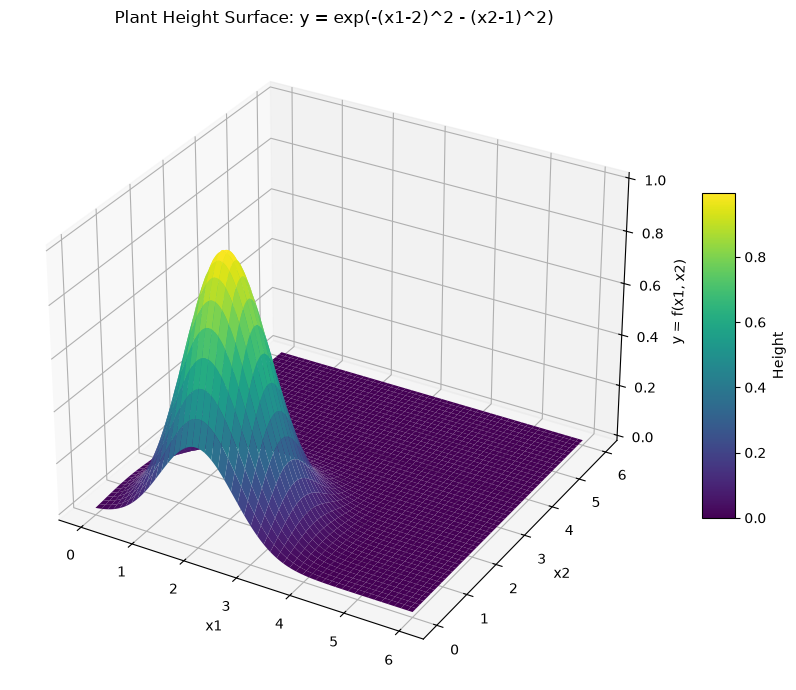

In [19]:
  # noqa: F401 (enables 3D projection)

# Domain
x1 = np.linspace(0, 6, 200)
x2 = np.linspace(0, 6, 200)
X1, X2 = np.meshgrid(x1, x2)

# Height function
Y = np.exp(-(X1 - 2)**2 - (X2 - 1)**2)

# 3D surface plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y = f(x1, x2)')
ax.set_title('Plant Height Surface: y = exp(-(x1-2)^2 - (x2-1)^2)')
fig.colorbar(surf, shrink=0.5, aspect=10, label='Height')

plt.tight_layout()
plt.show()

# Statistics

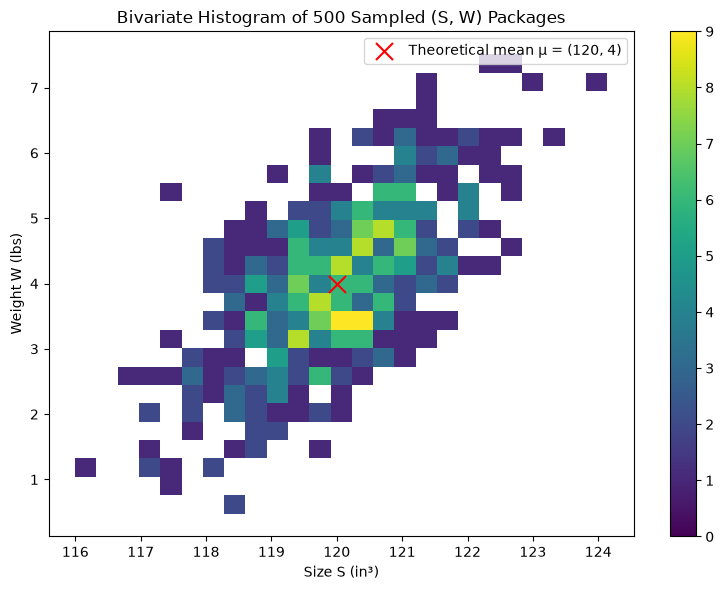

In [20]:
# ── Set up the joint distribution ────────────────────────────────
np.random.seed(42)  # reproducibility

mu = np.array([120, 4])          # [mean size, mean weight]
Sigma = np.array([[1.5, 1],
                   [1,   1.5]])

# ── Sample 500 (S, W) pairs from the joint distribution ──────────
samples = multivariate_normal.rvs(mean=mu, cov=Sigma, size=500, random_state=42)
S_samples = samples[:, 0]
W_samples = samples[:, 1]

# ── Bivariate histogram ────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.histplot(x=S_samples, y=W_samples, bins=25, cbar=True, cmap='viridis')
plt.scatter(mu[0], mu[1], color='red', marker='x', s=150,
            label=f'Theoretical mean μ = ({mu[0]}, {mu[1]})')
plt.xlabel('Size S (in³)')
plt.ylabel('Weight W (lbs)')
plt.title('Bivariate Histogram of 500 Sampled (S, W) Packages')
plt.legend()
plt.tight_layout()
plt.show()

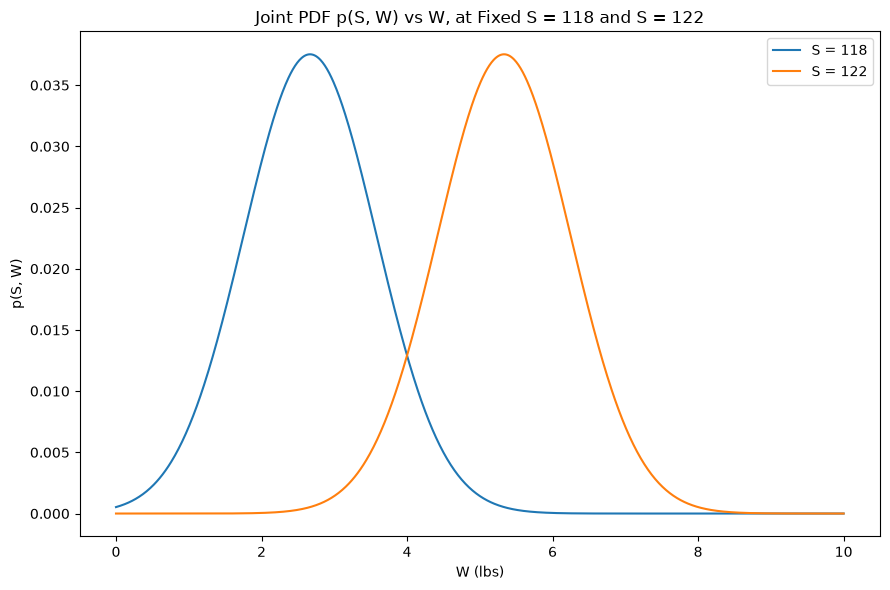

In [21]:
# ── Joint distribution parameters ────────────────────────────────
mu = np.array([120, 4])
Sigma = np.array([[1.5, 1],
                   [1,   1.5]])
rv = multivariate_normal(mean=mu, cov=Sigma)

# ── W grid: 1001 evenly-spaced values between 0 and 10 ───────────
W_vals = np.linspace(0, 10, 1001)

# ── Evaluate joint PDF p(S, W) at fixed S = 118 and S = 122 ──────
S_low, S_high = 118, 122

points_low  = np.column_stack([np.full_like(W_vals, S_low),  W_vals])
points_high = np.column_stack([np.full_like(W_vals, S_high), W_vals])

pdf_low  = rv.pdf(points_low)
pdf_high = rv.pdf(points_high)

# ── Plot both slices together ─────────────────────────────────────
plt.figure(figsize=(9, 6))
plt.plot(W_vals, pdf_low,  label=f'S = {S_low}',  color='tab:blue')
plt.plot(W_vals, pdf_high, label=f'S = {S_high}', color='tab:orange')
plt.xlabel('W (lbs)')
plt.ylabel('p(S, W)')
plt.title('Joint PDF p(S, W) vs W, at Fixed S = 118 and S = 122')
plt.legend()
plt.tight_layout()
plt.show()

# Linear Regression

In [33]:
data = pd.read_csv("https://raw.githubusercontent.com/harvard-ml-courses/cs181-s26-homeworks/refs/heads/main/hw0/data/points.csv")
x = data['x'].to_numpy()
y = data['y'].to_numpy()

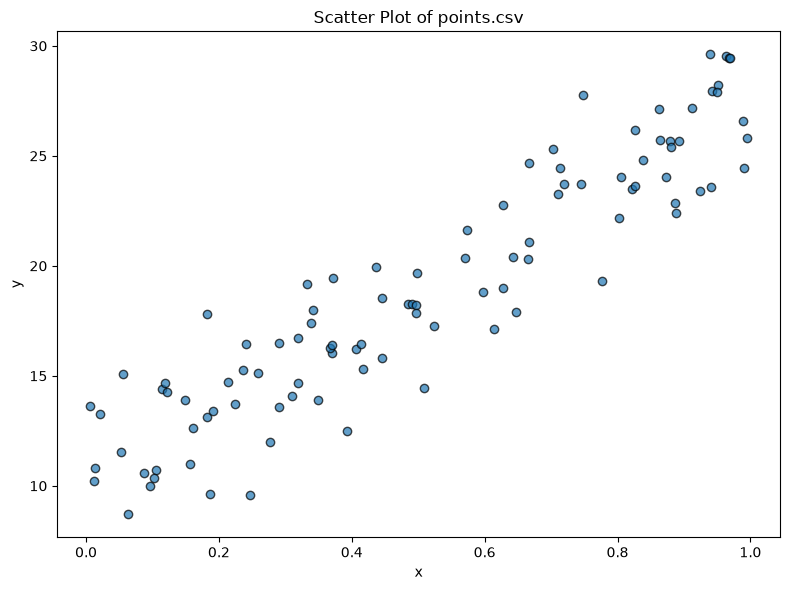

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of points.csv')
plt.tight_layout()
plt.show()

In [37]:
intercept = np.ones((x.shape[0], 1))          # shape (100, 1) — a genuine column
X = np.hstack([intercept, x.reshape(-1, 1)])  # x also reshaped to (100, 1)
X.shape

(100, 2)

In [38]:
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        """
        Fit linear model to the data, estimating weights w.
        """
        self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        """
        Use fitted weights to predict target y given input features X.
        """
        return X @ self.w

In [39]:
# ── Fit the model ───────────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)
print("Fitted weights (w):", model.w)

Fitted weights (w): [10.23322606 17.07154804]


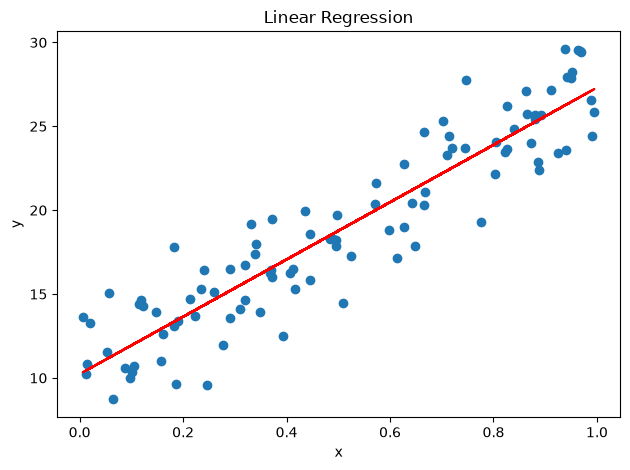

In [43]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
# Plot the data and the regression line
plt.scatter(X[:, 1], y)
plt.plot(X[:, 1], y_pred, color='red')
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()

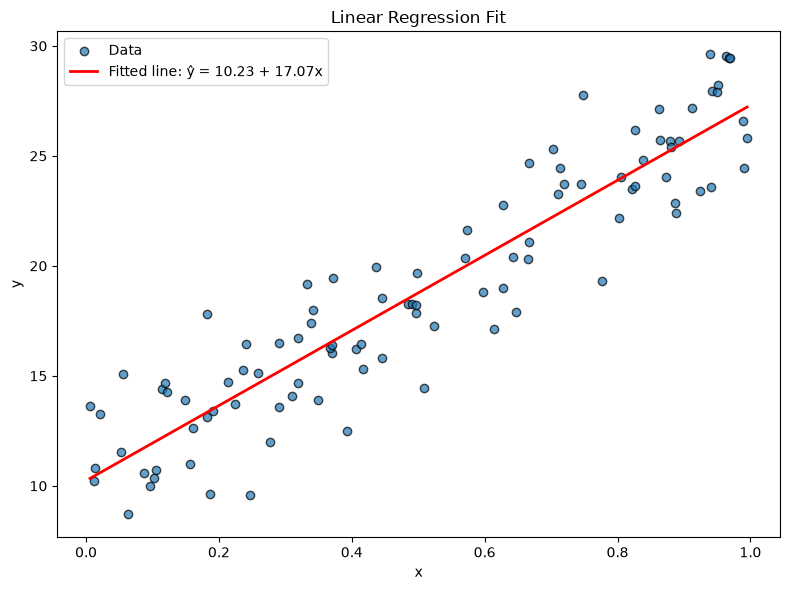

In [40]:
# ── Predict over a smooth range of x for plotting the fitted line ──
x_line = np.linspace(x.min(), x.max(), 200)
X_line = np.hstack([np.ones((x_line.shape[0], 1)), x_line.reshape(-1, 1)])
y_pred_line = model.predict(X_line)

# ── Predictions on the actual data points, for residual/fit check ──
y_pred = model.predict(X)

# ── Plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, edgecolor='k', label='Data')
plt.plot(x_line, y_pred_line, color='red', linewidth=2,
         label=f'Fitted line: ŷ = {model.w[0]:.2f} + {model.w[1]:.2f}x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.tight_layout()

In [41]:
mse = np.mean((y - y_pred)**2)
mse

np.float64(4.439331220193987)